In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from xgboost import XGBClassifier

In [2]:
train = pd.read_csv('/kaggle/input/competitions/playground-series-s6e4/train.csv')
test  = pd.read_csv('/kaggle/input/competitions/playground-series-s6e4/test.csv')

In [3]:
test_id = test['id']

In [4]:
train.columns

Index(['id', 'Soil_Type', 'Soil_pH', 'Soil_Moisture', 'Organic_Carbon',
       'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm',
       'Sunlight_Hours', 'Wind_Speed_kmh', 'Crop_Type', 'Crop_Growth_Stage',
       'Season', 'Irrigation_Type', 'Water_Source', 'Field_Area_hectare',
       'Mulching_Used', 'Previous_Irrigation_mm', 'Region', 'Irrigation_Need'],
      dtype='object')

In [5]:
def engineer_features(df):
    df = df.copy()

    # ── Water Stress & Balance ─────────────────────────────────────────────
    # Standard environmental ratios
    df['moisture_temp_ratio']      = df['Soil_Moisture'] / (df['Temperature_C'] + 1)
    df['moisture_deficit']         = df['Temperature_C'] - df['Soil_Moisture']
    df['evapotranspiration']       = (df['Temperature_C'] * df['Sunlight_Hours']) / (df['Humidity'] + 1)
    df['water_balance']            = df['Rainfall_mm'] - df['evapotranspiration']
    
    # New: Interaction with previous irrigation
    df['total_water_available']    = df['Rainfall_mm'] + df['Previous_Irrigation_mm']
    df['moisture_per_hectare']     = df['Soil_Moisture'] / (df['Field_Area_hectare'] + 0.1)

    # ── Environmental Effectiveness ────────────────────────────────────────
    df['effective_rainfall']       = df['Rainfall_mm'] * (1 - df['Wind_Speed_kmh'] / 100)
    df['rainfall_humidity']        = df['Rainfall_mm'] * df['Humidity'] / 100
    df['dryness_index']            = (df['Temperature_C'] * df['Sunlight_Hours']) / (df['Rainfall_mm'] + 1)
    df['heat_stress']              = df['Sunlight_Hours'] * df['Temperature_C']
    df['humidity_deficit']         = 100 - df['Humidity']

    # ── Soil & Salinity ────────────────────────────────────────────────────
    # High EC and low pH can indicate a need for leaching/flushing with water
    df['salinity_stress']          = df['Electrical_Conductivity'] * df['Temperature_C']
    df['ph_moisture_interaction']  = df['Soil_pH'] * df['Soil_Moisture']

    # ── Log & Sqrt transforms ─────────────────────────────────────────────
    # Applied to skewed numerical columns present in S6E4
    skewed_cols = ['Rainfall_mm', 'Wind_Speed_kmh', 'Previous_Irrigation_mm', 'Field_Area_hectare']
    for col in skewed_cols:
        df[f'log_{col}'] = np.log1p(df[col].clip(0))
        
    for col in ['Rainfall_mm', 'Previous_Irrigation_mm']:
        df[f'sqrt_{col}'] = np.sqrt(df[col].clip(0))

    # ── Binned features ────────────────────────────────────────────────────
    df['temp_bin']     = pd.cut(df['Temperature_C'], bins=[0, 15, 25, 35, 100], 
                                labels=[0, 1, 2, 3]).astype(int)
    df['moisture_bin'] = pd.cut(df['Soil_Moisture'], bins=[0, 20, 40, 60, 100], 
                                labels=[0, 1, 2, 3]).astype(int)
    df['rainfall_bin'] = pd.cut(df['Rainfall_mm'], bins=[-1, 5, 20, 50, 10000], 
                                labels=[0, 1, 2, 3]).astype(int)

    # ── Domain Ordinal Mappings ────────────────────────────────────────────
    # Adjusted to match standard S6E4 category names
    growth_risk  = {'Seedling': 3, 'Vegetative': 2, 'Flowering': 3, 'Fruiting': 3,
                    'Maturity': 1, 'Harvesting': 0}
    season_risk  = {'Summer': 3, 'Spring': 2, 'Autumn': 1, 'Winter': 0}
    soil_ret     = {'Sandy': 0, 'Loamy': 2, 'Clay': 3, 'Silty': 2, 'Peaty': 2, 'Chalky': 1}

    df['growth_risk']            = df['Crop_Growth_Stage'].map(growth_risk).fillna(1)
    df['season_risk']            = df['Season'].map(season_risk).fillna(1)
    df['soil_retention']         = df['Soil_Type'].map(soil_ret).fillna(1)
    
    df['growth_moisture_stress'] = df['growth_risk'] * df['moisture_deficit']
    df['soil_rain_interaction']  = df['soil_retention'] * df['Rainfall_mm']

    # ── Composite Irrigation Pressure Score ───────────────────────────────
    df['irrigation_pressure'] = (
        df['season_risk'] +
        df['growth_risk'] +
        (df['Soil_Moisture'] < 30).astype(int) * 2 +
        (df['Rainfall_mm']   < 10).astype(int) * 2 +
        (df['Temperature_C'] > 30).astype(int) +
        (df['Humidity']      < 40).astype(int) +
        (df['Mulching_Used'] == 'No').astype(int) # Mulching reduces water need
    )

    # ── XGBoost-specific: Polynomial Interactions ──────────────────────────
    df['moisture_x_rainfall']    = df['Soil_Moisture'] * df['Rainfall_mm']
    df['temp_x_humidity']        = df['Temperature_C'] * df['Humidity']
    df['sun_x_wind']             = df['Sunlight_Hours'] * df['Wind_Speed_kmh']
    df['pressure_x_deficit']     = df['irrigation_pressure'] * df['moisture_deficit']
    df['area_x_growth']          = df['Field_Area_hectare'] * df['growth_risk']

    return df

In [6]:
train = engineer_features(train)
test  = engineer_features(test)
print(f"Features after engineering: {train.shape[1]}")

Features after engineering: 54


In [7]:
CAT_COLS = ['Soil_Type', 'Crop_Type', 'Irrigation_Type',
            'Water_Source', 'Crop_Growth_Stage', 'Season']

oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
combined_cats = pd.concat([train[CAT_COLS], test[CAT_COLS]], axis=0)
oe.fit(combined_cats)

train[CAT_COLS] = oe.transform(train[CAT_COLS]).astype(int)
test[CAT_COLS]  = oe.transform(test[CAT_COLS]).astype(int)

class_order = ['Low', 'Medium', 'High']
target_map  = {cls: i for i, cls in enumerate(class_order)}
inv_map     = {v: k for k, v in target_map.items()}

In [8]:
X            = train.drop(columns=['id', 'Irrigation_Need'])
y            = train['Irrigation_Need'].map(target_map)
X_test_final = test.drop(columns=['id'])

print(f"Total features : {X.shape[1]}")
print(f"Target balance :\n{y.value_counts().rename(inv_map)}\n")

Total features : 52
Target balance :
Irrigation_Need
Low       369917
Medium    239074
High       21009
Name: count, dtype: int64



In [9]:
# Identify object columns and convert to category
for col in X.select_dtypes(include=['object']).columns:
    X[col] = X[col].astype('category')
    X_test_final[col] = X_test_final[col].astype('category')

In [10]:
PARAMS = {
    'objective':        'multi:softprob',
    'num_class':        3,
    'eval_metric':      'mlogloss',
    'n_estimators':     3000,
    'learning_rate':    0.02,
    'max_depth':        7,
    'max_leaves':       128,
    'grow_policy':      'lossguide',    # leaf-wise like LightGBM
    'min_child_weight': 30,             # analogous to min_child_samples
    'gamma':            0.05,           # min loss reduction to split (XGB only)
    'subsample':        0.8,
    'colsample_bytree': 0.8,
    'colsample_bylevel':0.8,            # extra column sampling per level (XGB only)
    'reg_alpha':        0.1,            # L1
    'reg_lambda':       1.5,            # L2 (XGB default is 1; increase helps)
    'max_delta_step':   1,              # stabilises multiclass updates
    'tree_method':      'hist',
    'device':           'cuda',         # change to 'cpu' if no GPU
    'random_state':     42,
    'verbosity':        0,
    'n_jobs':           -1,
    'enable_categorical': True
}

In [11]:
N_FOLDS    = 5
skf        = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

oof_probs  = np.zeros((len(X), 3))
test_probs = np.zeros((len(X_test_final), 3))
fold_f1s   = []

print("=" * 55)
print(f"  Running {N_FOLDS}-Fold Stratified CV (Multiclass XGBoost)")
print("=" * 55 + "\n")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = XGBClassifier(**PARAMS, early_stopping_rounds=100)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    val_prob           = model.predict_proba(X_val)
    val_pred           = np.argmax(val_prob, axis=1)
    fold_f1            = f1_score(y_val, val_pred, average='macro')
    fold_f1s.append(fold_f1)

    oof_probs[val_idx] = val_prob
    test_probs        += model.predict_proba(X_test_final) / N_FOLDS

    print(f"  Fold {fold}  Macro-F1: {fold_f1:.5f}  |  Best iter: {model.best_iteration}")


  Running 5-Fold Stratified CV (Multiclass XGBoost)

  Fold 1  Macro-F1: 0.97094  |  Best iter: 2316
  Fold 2  Macro-F1: 0.97076  |  Best iter: 2124
  Fold 3  Macro-F1: 0.97104  |  Best iter: 2400
  Fold 4  Macro-F1: 0.97070  |  Best iter: 2451
  Fold 5  Macro-F1: 0.97159  |  Best iter: 2263


In [12]:
oof_preds  = np.argmax(oof_probs, axis=1)
overall_f1 = f1_score(y, oof_preds, average='macro')

print(f"\n{'='*55}")
print(f"  CV  Macro-F1 (mean ± std) : {np.mean(fold_f1s):.5f} ± {np.std(fold_f1s):.5f}")
print(f"  Overall OOF Macro-F1      : {overall_f1:.5f}")
print(f"{'='*55}\n")

print("Per-Class Report (OOF):")
print(classification_report(y, oof_preds, target_names=class_order))


  CV  Macro-F1 (mean ± std) : 0.97100 ± 0.00032
  Overall OOF Macro-F1      : 0.97100

Per-Class Report (OOF):
              precision    recall  f1-score   support

         Low       0.99      1.00      0.99    369917
      Medium       0.99      0.97      0.98    239074
        High       0.97      0.92      0.94     21009

    accuracy                           0.98    630000
   macro avg       0.98      0.96      0.97    630000
weighted avg       0.98      0.98      0.98    630000



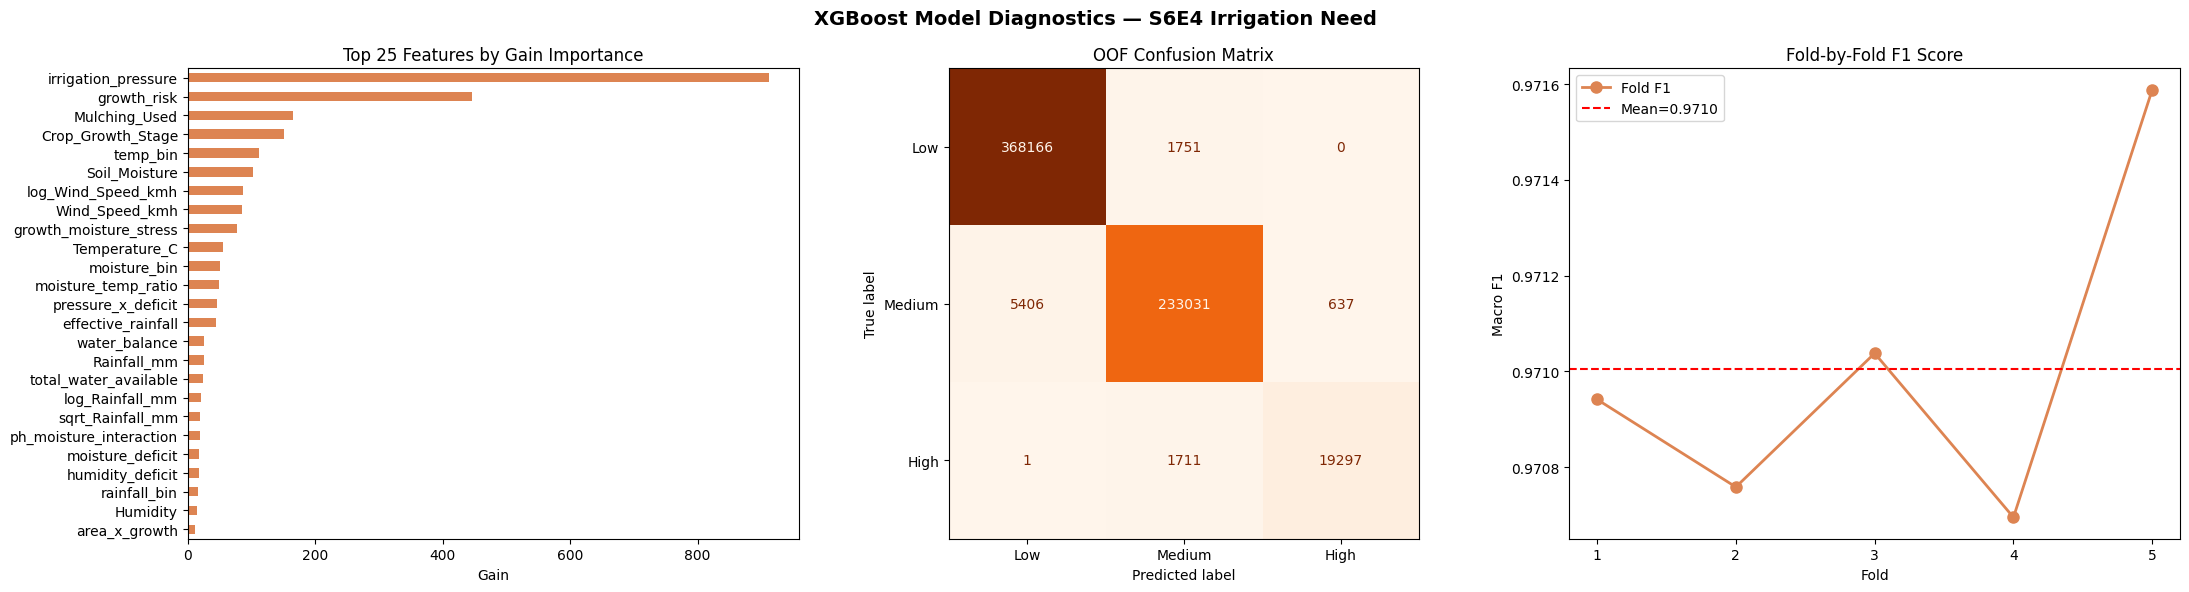

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# 7a. Feature importance (gain)
feat_imp = pd.Series(
    model.get_booster().get_score(importance_type='gain'),
).sort_values(ascending=True)

feat_imp.tail(25).plot(kind='barh', ax=axes[0], color='#DD8452')
axes[0].set_title('Top 25 Features by Gain Importance')
axes[0].set_xlabel('Gain')

# 7b. OOF Confusion Matrix
cm   = confusion_matrix(y, oof_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=class_order)
disp.plot(ax=axes[1], colorbar=False, cmap='Oranges')
axes[1].set_title('OOF Confusion Matrix')

# 7c. Fold-by-fold F1 trend
axes[2].plot(range(1, N_FOLDS+1), fold_f1s, marker='o', color='#DD8452',
             linewidth=2, markersize=8, label='Fold F1')
axes[2].axhline(np.mean(fold_f1s), color='red', linestyle='--', label=f'Mean={np.mean(fold_f1s):.4f}')
axes[2].set_xlabel('Fold')
axes[2].set_ylabel('Macro F1')
axes[2].set_title('Fold-by-Fold F1 Score')
axes[2].legend()
axes[2].set_xticks(range(1, N_FOLDS+1))

plt.suptitle('XGBoost Model Diagnostics — S6E4 Irrigation Need', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [14]:
final_labels = [inv_map[p] for p in np.argmax(test_probs, axis=1)]

submission = pd.DataFrame({
    'id':              test_id,
    'Irrigation_Need': final_labels
})
submission.to_csv('submission.csv', index=False)
print("submission.csv saved!")
print(submission['Irrigation_Need'].value_counts())
print(submission.head())

submission.csv saved!
Irrigation_Need
Low       159906
Medium    101454
High        8640
Name: count, dtype: int64
       id Irrigation_Need
0  630000             Low
1  630001             Low
2  630002             Low
3  630003             Low
4  630004             Low
